# Notebook 4: Customer Spend Regression Models

**Project Title**: Intelligent Customer Behavior Analysis and Dynamic Marketing Strategy  
**Objective**: This notebook implements regression modeling to forecast future spend on a customer level using the operational window definitions.

### Regression Operational Window Setup:
- **Features (Months 1-9)**: Customer Recency, Frequency, Monetary spend, PC1, and PC2 computed from transactions spanning `2009-12-01` to `2010-08-31`.
- **Target (Future Spend, Months 10-12)**: Total sum of transactions for each customer spanning `2010-09-01` to `2010-11-30` (defaults to 0 for customers who did not buy in this window).

### What We Will Accomplish:
1. Construct the regression datasets at the customer level.
2. Standardize features and perform Train/Val/Test customer splits (reusing the same seed 42).
3. Fit **Model 1**: MLPRegressor and **Model 2**: LinearRegression.
4. Compare performance metrics: MSE, RMSE, MAE, R² in a table.
5. Render predicted vs actual scatter plots and residual plots.
6. Save the champion regression model for use in Reinforcement Learning.

### Step 1: Import Modules and Load Raw Data
Import preprocessing, regression models, and plotting helpers.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sys.path.append(os.path.abspath('../'))
from src.preprocessing import load_and_clean_data, get_category_map, create_regression_dataset, split_customers
from src.modeling import train_regressor_mlp, train_regressor_linear, evaluate_regressor, save_model
from src.utils import plot_predicted_vs_actual, plot_residual_plot

%matplotlib inline
print("Libraries successfully imported!")

Libraries successfully imported!


### Step 2: Build Regression Dataset at Customer Level
We split clean transactions into the feature window (Months 1-9) and target window (Months 10-12).

In [2]:
raw_df = load_and_clean_data('../online_retail_II.csv')
category_map = get_category_map('../category_map.json')

print("Building Months 1-9 features and Months 10-12 target spend...")
reg_df = create_regression_dataset(
    raw_df, category_map,
    f_start='2009-12-01', f_end='2010-08-31',
    t_start='2010-09-01', t_end='2010-11-30'
)
print(f"Regression customer profiles dataset shape: {reg_df.shape}")
reg_df.head()

Building Months 1-9 features and Months 10-12 target spend...


Regression customer profiles dataset shape: (3313, 13)


,CustomerID,Frequency,Monetary,Product_Diversity,Recency,Average_Spend_Per_Transaction,Homeware_Spend_Pct,Stationery_Spend_Pct,Gadgets_Spend_Pct,Decorations_Spend_Pct,Kitchenware_Spend_Pct,Else_Spend_Pct,Future_Spend
0,12346,11,372.86,26,64,33.896364,0.080352,0.000000,0.000000,0.040176,0.020088,0.859384,0.00
1,12349,2,1268.52,47,105,634.260000,0.081229,0.006149,0.000000,0.000000,0.155299,0.757323,1402.62
2,12355,1,488.21,22,102,488.210000,0.098073,0.084554,0.040966,0.000000,0.081727,0.694681,0.00
3,12358,2,1697.93,34,85,848.965000,0.033588,0.047705,0.000000,0.000000,0.047587,0.871120,1021.08
4,12359,5,2012.03,82,70,402.406000,0.048086,0.059641,0.000000,0.000000,0.265876,0.626397,551.33


### Step 3: Project PCA Features and Apply Splitting
We load our saved category scaler and PCA projection matrices to append PC1 and PC2, then perform customer splitting.

In [3]:
# Load saved scaler and PCA models
scaler = joblib.load('../models/category_scaler.pkl')
pca = joblib.load('../models/pca_model.pkl')

# Extract and standardize category features for regression dataset
cat_cols = [c for c in reg_df.columns if c.endswith('_Spend_Pct')]
scaled_cat = scaler.transform(reg_df[cat_cols])
pc_proj = pca.transform(scaled_cat)

reg_df['PC1'] = pc_proj[:, 0]
reg_df['PC2'] = pc_proj[:, 1]

# Perform customer level split using customer IDs
train_cust, val_cust, test_cust = split_customers(reg_df['CustomerID'], random_state=42)

reg_df['Split'] = 'Train'
reg_df.loc[reg_df['CustomerID'].isin(val_cust), 'Split'] = 'Val'
reg_df.loc[reg_df['CustomerID'].isin(test_cust), 'Split'] = 'Test'

print(f"Split counts - Train: {len(train_cust)}, Val: {len(val_cust)}, Test: {len(test_cust)}")

Split counts - Train: 2650, Val: 331, Test: 332


C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


### Step 4: Extract Regressor Matrices
We prepare features (`Recency`, `Frequency`, `Monetary`, `PC1`, `PC2`) and targets (`Future_Spend`).

In [4]:
feature_cols = ['Recency', 'Frequency', 'Monetary', 'PC1', 'PC2']

X_train = reg_df[reg_df['Split'] == 'Train'][feature_cols]
y_train = reg_df[reg_df['Split'] == 'Train']['Future_Spend']

X_val = reg_df[reg_df['Split'] == 'Val'][feature_cols]
y_val = reg_df[reg_df['Split'] == 'Val']['Future_Spend']

X_test = reg_df[reg_df['Split'] == 'Test'][feature_cols]
y_test = reg_df[reg_df['Split'] == 'Test']['Future_Spend']

### Step 5: Fit Regression Models
We fit MLPRegressor and LinearRegression models on the training set.

In [5]:
print("Training MLP Regressor...")
mlp_reg = train_regressor_mlp(X_train, y_train, random_state=42)

print("Training Linear Regression...")
lr_reg = train_regressor_linear(X_train, y_train)

print("Training complete.")

Training MLP Regressor...


Training Linear Regression...
Training complete.


### Step 6: Evaluate Models and Report Metrics
We score both regressors on validation data and choose the best performer to run on the Test set.

In [6]:
mlp_val = evaluate_regressor(mlp_reg, X_val, y_val)
lr_val = evaluate_regressor(lr_reg, X_val, y_val)

val_summary = pd.DataFrame([mlp_val, lr_val], index=['MLP Regressor', 'Linear Regression'])
print("Validation Set Comparison:")
print(val_summary)

# Select best based on validation R^2
best_name = 'MLP Regressor' if mlp_val['R2'] >= lr_val['R2'] else 'Linear Regression'
best_model = mlp_reg if best_name == 'MLP Regressor' else lr_reg
print(f"\nChampion Regressor model: {best_name}")

# Evaluate on test
test_metrics = evaluate_regressor(best_model, X_test, y_test)
print(f"=== TEST SET EVALUATION ({best_name}) ===")
for m, val in test_metrics.items():
    print(f"{m}: {val:.4f}")

Validation Set Comparison:
                            MSE         RMSE         MAE        R2
MLP Regressor      5.015331e+06  2239.493487  568.568865  0.061429
Linear Regression  4.877960e+06  2208.610364  578.096649  0.087137

Champion Regressor model: Linear Regression
=== TEST SET EVALUATION (Linear Regression) ===
MSE: 1420285.2400
RMSE: 1191.7572
MAE: 498.4535
R2: 0.8035


### Step 7: Plot Predicted vs Actual Spend & Residual Plots
We plot diagnostics using our helper utilities and save the figures.

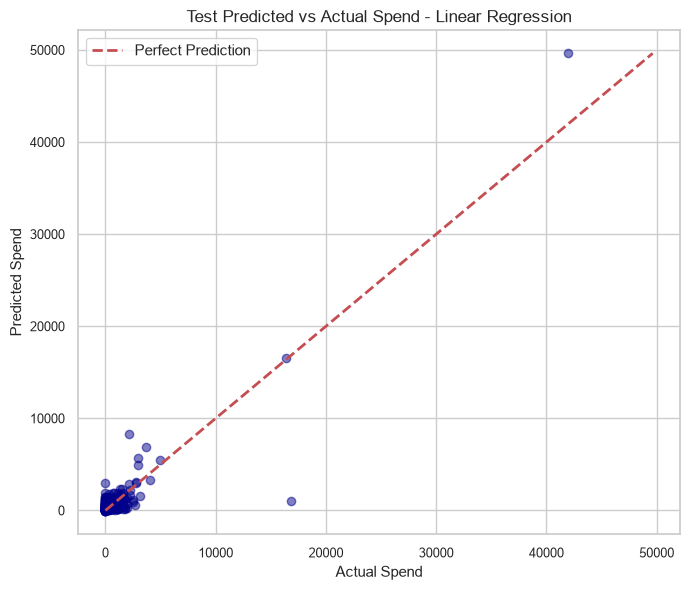

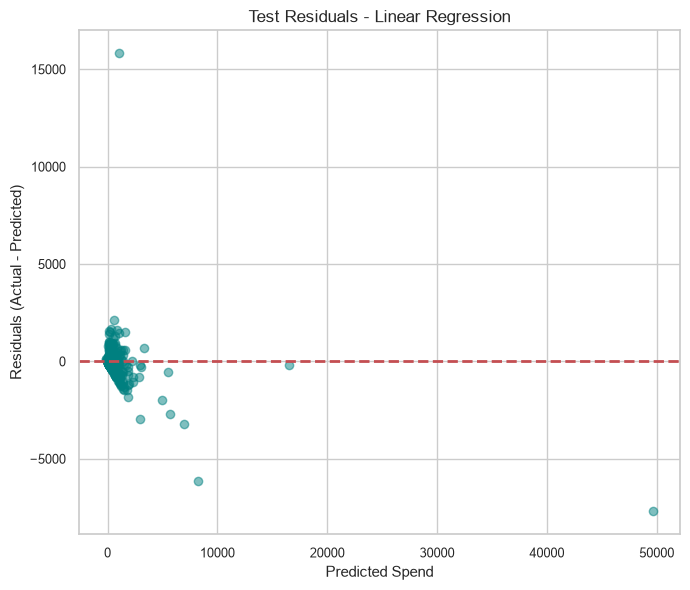

In [7]:
y_test_pred = best_model.predict(X_test)

fig_pva = plot_predicted_vs_actual(y_test.values, y_test_pred, title=f'Test Predicted vs Actual Spend - {best_name}', save_path='../data/plots/reg_predicted_vs_actual.png')
fig_res = plot_residual_plot(y_test.values, y_test_pred, title=f'Test Residuals - {best_name}', save_path='../data/plots/reg_residuals.png')
plt.show()

### Step 8: Save Regression Dataset and Model
We save the regression target mappings and serialize the best regression model.

In [8]:
reg_df.to_csv('../data/regression_customers.csv', index=False)
save_model(best_model, '../models/best_regressor.pkl')
print("Regressor model saved to models/best_regressor.pkl successfully!")

Regressor model saved to models/best_regressor.pkl successfully!
